# 04 — Statistical Analysis

## Brazilian E-Commerce Analytics Portfolio

This notebook performs statistical analysis on the Olist e-commerce dataset.

### Objectives

1. Build reusable analytical tables.
2. Compare review scores between late and on-time deliveries.
3. Test the relationship between delivery delay and review score.
4. Analyze the relationship between order value and payment installments.
5. Compare customer value between one-time and repeat customers.
6. Evaluate whether review scores differ by payment type.
7. Export statistical-test results, figures, and a Markdown statistical report.

### Important interpretation note

Statistical association does not imply causation. Results should be interpreted as exploratory evidence rather than causal proof.

## Methodology workflow

```text
Raw Olist relational datasets
        ↓
Build analytical tables
        ↓
Define statistical questions
        ↓
Prepare valid samples for each test
        ↓
Run descriptive statistics
        ↓
Apply statistical tests and effect-size measures
        ↓
Generate diagnostic figures
        ↓
Export statistical results and report
```

The corresponding workflow image can be stored as:

```text
workflows/04_statistical_analysis_workflow.png
```

## 1. Import libraries and configure the environment

In [1]:
from pathlib import Path
from typing import Dict, Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 160)

print(f"Pandas version: {pd.__version__}")
print(f"NumPy version:  {np.__version__}")

Pandas version: 2.2.2
NumPy version:  2.0.2


## 2. Resolve project paths and locate the raw data

In [2]:
def find_local_raw_data(start_path: Path) -> Path | None:
    """Find a local data/raw directory containing the Olist CSV files."""
    required_file = "olist_orders_dataset.csv"
    start_path = start_path.resolve()

    for candidate in [start_path, *start_path.parents]:
        raw_dir = candidate / "data" / "raw"
        if (raw_dir / required_file).exists():
            return raw_dir

    return None


PROJECT_ROOT = Path.cwd()
LOCAL_RAW_DATA_DIR = find_local_raw_data(PROJECT_ROOT)

if LOCAL_RAW_DATA_DIR is not None:
    RAW_DATA_DIR = LOCAL_RAW_DATA_DIR
    PROJECT_ROOT = RAW_DATA_DIR.parents[1]
    print("Using local data/raw directory.")
else:
    try:
        import kagglehub
    except ImportError as exc:
        raise ImportError(
            "kagglehub is not installed and local data/raw was not found. "
            "Install it with: pip install kagglehub"
        ) from exc

    RAW_DATA_DIR = Path(
        kagglehub.dataset_download("olistbr/brazilian-ecommerce")
    )
    print("Using KaggleHub dataset directory.")

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root:       {PROJECT_ROOT}")
print(f"Raw data directory: {RAW_DATA_DIR}")
print(f"Processed data:     {PROCESSED_DATA_DIR}")
print(f"Reports directory:  {REPORTS_DIR}")
print(f"Figures directory:  {FIGURES_DIR}")

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Using KaggleHub dataset directory.
Project root:       /content
Raw data directory: /kaggle/input/brazilian-ecommerce
Processed data:     /content/data/processed
Reports directory:  /content/reports
Figures directory:  /content/reports/figures


## 3. Load the Olist datasets

In [3]:
FILE_NAMES = {
    "customers": "olist_customers_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "payments": "olist_order_payments_dataset.csv",
    "reviews": "olist_order_reviews_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}

DATE_COLUMNS = {
    "orders": [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
    "order_items": ["shipping_limit_date"],
    "reviews": [
        "review_creation_date",
        "review_answer_timestamp",
    ],
}


def load_dataset(file_path: Path, date_columns: Iterable[str] | None = None) -> pd.DataFrame:
    """Load one CSV file and parse date columns when available."""
    dataframe = pd.read_csv(file_path, low_memory=False)

    if date_columns:
        for column in date_columns:
            if column in dataframe.columns:
                dataframe[column] = pd.to_datetime(dataframe[column], errors="coerce")

    return dataframe


missing_files = [
    file_name for file_name in FILE_NAMES.values()
    if not (RAW_DATA_DIR / file_name).exists()
]

if missing_files:
    missing_text = "\n".join(f"- {name}" for name in missing_files)
    raise FileNotFoundError(f"Missing required files:\n{missing_text}")

datasets: Dict[str, pd.DataFrame] = {}

for dataset_name, file_name in FILE_NAMES.items():
    datasets[dataset_name] = load_dataset(
        RAW_DATA_DIR / file_name,
        DATE_COLUMNS.get(dataset_name),
    )

for dataset_name, dataframe in datasets.items():
    print(f"{dataset_name:<22} {dataframe.shape[0]:>8,} rows × {dataframe.shape[1]:>2} columns")

customers                99,441 rows ×  5 columns
orders                   99,441 rows ×  8 columns
order_items             112,650 rows ×  7 columns
payments                103,886 rows ×  5 columns
reviews                  99,224 rows ×  7 columns
products                 32,951 rows ×  9 columns
sellers                   3,095 rows ×  4 columns
category_translation         71 rows ×  2 columns


## 4. Build analytical tables

In [4]:
def build_analytical_tables(datasets: Dict[str, pd.DataFrame]) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Create order-level, customer-level, and item-product analytical tables."""
    customers = datasets["customers"].copy()
    orders = datasets["orders"].copy()
    order_items = datasets["order_items"].copy()
    payments = datasets["payments"].copy()
    reviews = datasets["reviews"].copy()
    products = datasets["products"].copy()
    category_translation = datasets["category_translation"].copy()

    items_with_products = (
        order_items
        .merge(products, on="product_id", how="left")
        .merge(category_translation, on="product_category_name", how="left")
    )
    items_with_products["product_category_name_english"] = (
        items_with_products["product_category_name_english"].fillna("unknown")
    )

    item_summary = (
        items_with_products
        .groupby("order_id", as_index=False)
        .agg(
            item_count=("order_item_id", "count"),
            unique_products=("product_id", "nunique"),
            unique_sellers=("seller_id", "nunique"),
            total_item_value=("price", "sum"),
            total_freight_value=("freight_value", "sum"),
        )
    )

    category_by_order = (
        items_with_products
        .groupby(["order_id", "product_category_name_english"], as_index=False)
        .agg(category_item_value=("price", "sum"))
        .sort_values(["order_id", "category_item_value"], ascending=[True, False])
        .drop_duplicates(subset=["order_id"], keep="first")
        .rename(columns={"product_category_name_english": "primary_product_category"})
        .loc[:, ["order_id", "primary_product_category"]]
    )

    payment_summary = (
        payments
        .groupby("order_id", as_index=False)
        .agg(
            payment_records=("payment_sequential", "count"),
            payment_types=("payment_type", "nunique"),
            max_installments=("payment_installments", "max"),
            total_payment_value=("payment_value", "sum"),
        )
    )

    main_payment_type = (
        payments
        .groupby(["order_id", "payment_type"], as_index=False)
        .size()
        .sort_values(["order_id", "size", "payment_type"], ascending=[True, False, True])
        .drop_duplicates(subset=["order_id"], keep="first")
        .rename(columns={"payment_type": "main_payment_type"})
        .loc[:, ["order_id", "main_payment_type"]]
    )

    review_summary = (
        reviews
        .assign(
            has_review_comment=lambda dataframe: (
                dataframe["review_comment_message"].notna()
                | dataframe["review_comment_title"].notna()
            )
        )
        .groupby("order_id", as_index=False)
        .agg(
            review_count=("review_id", "count"),
            average_review_score=("review_score", "mean"),
            has_review_comment=("has_review_comment", "max"),
        )
    )

    order_level = (
        orders
        .merge(customers, on="customer_id", how="left")
        .merge(item_summary, on="order_id", how="left")
        .merge(category_by_order, on="order_id", how="left")
        .merge(payment_summary, on="order_id", how="left")
        .merge(main_payment_type, on="order_id", how="left")
        .merge(review_summary, on="order_id", how="left")
    )

    order_level["order_purchase_month"] = order_level["order_purchase_timestamp"].dt.to_period("M").astype("string")
    order_level["actual_delivery_days"] = (
        order_level["order_delivered_customer_date"] - order_level["order_purchase_timestamp"]
    ).dt.total_seconds() / 86400
    order_level["delivery_delay_days"] = (
        order_level["order_delivered_customer_date"] - order_level["order_estimated_delivery_date"]
    ).dt.total_seconds() / 86400
    order_level["is_delivered"] = order_level["order_status"].eq("delivered")
    order_level["is_late_delivery"] = np.where(
        order_level["order_delivered_customer_date"].notna(),
        order_level["delivery_delay_days"] > 0,
        np.nan,
    )
    order_level["has_review_comment"] = order_level["has_review_comment"].fillna(False).astype(bool)

    customer_level = (
        order_level
        .groupby("customer_unique_id", as_index=False)
        .agg(
            customer_state=("customer_state", "first"),
            customer_city=("customer_city", "first"),
            first_purchase_timestamp=("order_purchase_timestamp", "min"),
            last_purchase_timestamp=("order_purchase_timestamp", "max"),
            total_orders=("order_id", "nunique"),
            delivered_orders=("is_delivered", "sum"),
            total_items=("item_count", "sum"),
            total_item_value=("total_item_value", "sum"),
            total_freight_value=("total_freight_value", "sum"),
            total_payment_value=("total_payment_value", "sum"),
            average_review_score=("average_review_score", "mean"),
        )
    )
    customer_level["average_order_value"] = (
        customer_level["total_payment_value"] / customer_level["total_orders"].replace({0: np.nan})
    )
    customer_level["is_repeat_customer"] = customer_level["total_orders"] > 1
    customer_level["customer_lifetime_days"] = (
        customer_level["last_purchase_timestamp"] - customer_level["first_purchase_timestamp"]
    ).dt.days

    return order_level, customer_level, items_with_products


order_level, customer_level, items_with_products = build_analytical_tables(datasets)

print(f"Order-level table:    {order_level.shape[0]:,} rows × {order_level.shape[1]} columns")
print(f"Customer-level table: {customer_level.shape[0]:,} rows × {customer_level.shape[1]} columns")
print(f"Item-product table:   {items_with_products.shape[0]:,} rows × {items_with_products.shape[1]} columns")

/tmp/ipykernel_715/1164517225.py:102: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  order_level["has_review_comment"] = order_level["has_review_comment"].fillna(False).astype(bool)


Order-level table:    99,441 rows × 31 columns
Customer-level table: 96,096 rows × 15 columns
Item-product table:   112,650 rows × 16 columns


## 5. Helper functions

In [5]:
def cohen_d(group_a: pd.Series, group_b: pd.Series) -> float:
    """Calculate Cohen's d for two independent samples."""
    values_a = group_a.dropna().astype(float)
    values_b = group_b.dropna().astype(float)
    n_a = len(values_a)
    n_b = len(values_b)
    if n_a < 2 or n_b < 2:
        return np.nan
    pooled_std = np.sqrt(((n_a - 1) * values_a.var(ddof=1) + (n_b - 1) * values_b.var(ddof=1)) / (n_a + n_b - 2))
    if pooled_std == 0:
        return np.nan
    return (values_a.mean() - values_b.mean()) / pooled_std


def summarize_group(dataframe: pd.DataFrame, group_column: str, value_column: str) -> pd.DataFrame:
    """Create descriptive statistics by group."""
    return (
        dataframe
        .dropna(subset=[group_column, value_column])
        .groupby(group_column, as_index=False)
        .agg(
            sample_size=(value_column, "count"),
            mean_value=(value_column, "mean"),
            median_value=(value_column, "median"),
            standard_deviation=(value_column, "std"),
            minimum=(value_column, "min"),
            maximum=(value_column, "max"),
        )
    )


statistical_results = []


def add_test_result(question, test_name, sample_size, statistic, p_value, effect_size_name=None, effect_size_value=None, interpretation=None):
    statistical_results.append({
        "question": question,
        "test_name": test_name,
        "sample_size": sample_size,
        "statistic": statistic,
        "p_value": p_value,
        "effect_size_name": effect_size_name,
        "effect_size_value": effect_size_value,
        "interpretation": interpretation,
    })

## 6. Question 1 — Are late deliveries associated with lower review scores?

In [6]:
late_delivery_sample = order_level.loc[
    order_level["order_delivered_customer_date"].notna()
    & order_level["average_review_score"].notna()
    & order_level["is_late_delivery"].notna()
].copy()
late_delivery_sample["delivery_group"] = np.where(late_delivery_sample["is_late_delivery"].astype(bool), "late", "on_time_or_early")

review_by_delivery_group = summarize_group(late_delivery_sample, "delivery_group", "average_review_score")
review_by_delivery_group

,delivery_group,sample_size,mean_value,median_value,standard_deviation,minimum,maximum
0,late,7662,2.566562,2.0,1.657714,1.0,5.0
1,on_time_or_early,88168,4.294151,5.0,1.146214,1.0,5.0


In [7]:
late_scores = late_delivery_sample.loc[late_delivery_sample["delivery_group"].eq("late"), "average_review_score"]
on_time_scores = late_delivery_sample.loc[late_delivery_sample["delivery_group"].eq("on_time_or_early"), "average_review_score"]

mannwhitney_result = stats.mannwhitneyu(late_scores, on_time_scores, alternative="two-sided")
late_delivery_cohen_d = cohen_d(late_scores, on_time_scores)

add_test_result(
    question="Are late deliveries associated with different review scores?",
    test_name="Mann-Whitney U test",
    sample_size=int(late_delivery_sample.shape[0]),
    statistic=float(mannwhitney_result.statistic),
    p_value=float(mannwhitney_result.pvalue),
    effect_size_name="Cohen's d: late minus on-time",
    effect_size_value=float(late_delivery_cohen_d),
    interpretation="Compares review-score distributions between late and on-time/early deliveries.",
)

pd.DataFrame(statistical_results)

,question,test_name,sample_size,statistic,p_value,effect_size_name,effect_size_value,interpretation
0,Are late deliveries associated with different ...,Mann-Whitney U test,95830,150716905.5,0.0,Cohen's d: late minus on-time,-1.445458,Compares review-score distributions between la...


/tmp/ipykernel_715/2170925518.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([on_time_scores.dropna(), late_scores.dropna()], labels=["on_time_or_early", "late"], showfliers=False)


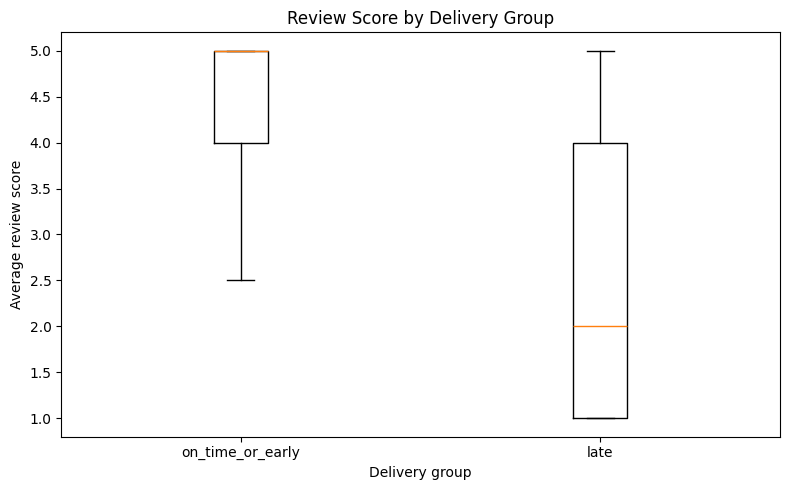

Saved figure: reports/figures/review_score_by_delivery_group.png


In [8]:
plt.figure(figsize=(8, 5))
plt.boxplot([on_time_scores.dropna(), late_scores.dropna()], labels=["on_time_or_early", "late"], showfliers=False)
plt.title("Review Score by Delivery Group")
plt.xlabel("Delivery group")
plt.ylabel("Average review score")
plt.tight_layout()
review_by_delivery_figure_path = FIGURES_DIR / "review_score_by_delivery_group.png"
plt.savefig(review_by_delivery_figure_path, dpi=150)
plt.show()
print(f"Saved figure: {review_by_delivery_figure_path.relative_to(PROJECT_ROOT)}")

## 7. Question 2 — Is delivery delay correlated with review score?

In [9]:
delay_review_sample = order_level.loc[
    order_level["delivery_delay_days"].notna()
    & order_level["average_review_score"].notna()
].copy()

spearman_delay_review = stats.spearmanr(delay_review_sample["delivery_delay_days"], delay_review_sample["average_review_score"])

add_test_result(
    question="Is delivery delay correlated with review score?",
    test_name="Spearman correlation",
    sample_size=int(delay_review_sample.shape[0]),
    statistic=float(spearman_delay_review.statistic),
    p_value=float(spearman_delay_review.pvalue),
    effect_size_name="Spearman rho",
    effect_size_value=float(spearman_delay_review.statistic),
    interpretation="Measures the monotonic association between delivery delay and review score.",
)

pd.DataFrame(statistical_results).tail(1)

,question,test_name,sample_size,statistic,p_value,effect_size_name,effect_size_value,interpretation
1,Is delivery delay correlated with review score?,Spearman correlation,95830,-0.17557,0.0,Spearman rho,-0.17557,Measures the monotonic association between del...


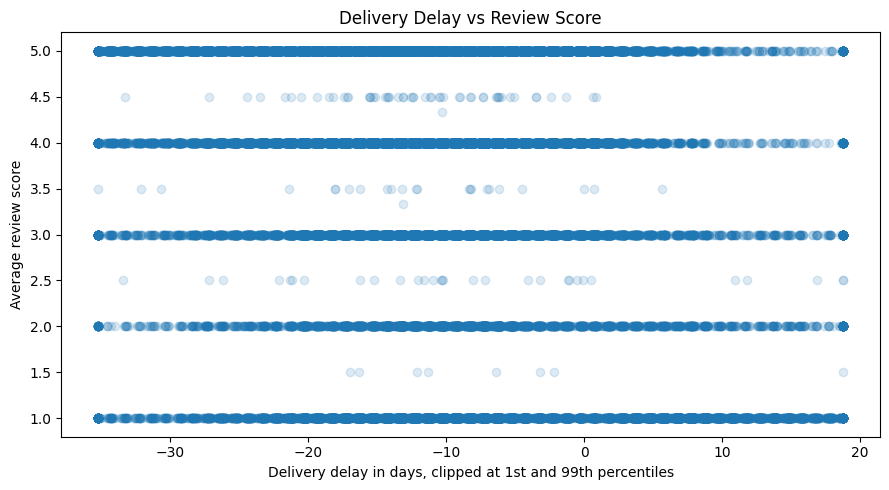

Saved figure: reports/figures/delivery_delay_vs_review_score.png


In [10]:
delay_plot = delay_review_sample.copy()
delay_plot["delivery_delay_days_clipped"] = delay_plot["delivery_delay_days"].clip(
    lower=delay_plot["delivery_delay_days"].quantile(0.01),
    upper=delay_plot["delivery_delay_days"].quantile(0.99),
)

plt.figure(figsize=(9, 5))
plt.scatter(delay_plot["delivery_delay_days_clipped"], delay_plot["average_review_score"], alpha=0.15)
plt.title("Delivery Delay vs Review Score")
plt.xlabel("Delivery delay in days, clipped at 1st and 99th percentiles")
plt.ylabel("Average review score")
plt.tight_layout()
delay_review_figure_path = FIGURES_DIR / "delivery_delay_vs_review_score.png"
plt.savefig(delay_review_figure_path, dpi=150)
plt.show()
print(f"Saved figure: {delay_review_figure_path.relative_to(PROJECT_ROOT)}")

## 8. Question 3 — Are larger orders associated with more installments?

In [11]:
installment_sample = order_level.loc[
    order_level["total_payment_value"].notna()
    & order_level["max_installments"].notna()
].copy()

spearman_value_installments = stats.spearmanr(installment_sample["total_payment_value"], installment_sample["max_installments"])

add_test_result(
    question="Are larger orders associated with more installments?",
    test_name="Spearman correlation",
    sample_size=int(installment_sample.shape[0]),
    statistic=float(spearman_value_installments.statistic),
    p_value=float(spearman_value_installments.pvalue),
    effect_size_name="Spearman rho",
    effect_size_value=float(spearman_value_installments.statistic),
    interpretation="Measures the monotonic association between payment value and maximum installments.",
)

installment_summary = (
    installment_sample
    .groupby("max_installments", as_index=False)
    .agg(order_count=("order_id", "nunique"), average_payment_value=("total_payment_value", "mean"), median_payment_value=("total_payment_value", "median"))
    .sort_values("max_installments")
)

display(installment_summary.head(20))
pd.DataFrame(statistical_results).tail(1)

,max_installments,order_count,average_payment_value,median_payment_value
0,0.0,2,94.315000,94.315
1,1.0,48268,121.037471,79.510
2,2.0,12363,129.124554,111.220
3,3.0,10429,144.362109,112.230
4,4.0,7070,165.060033,117.850
5,5.0,5227,184.888619,127.330
6,6.0,3908,211.594335,139.160
7,7.0,1622,189.335475,140.075
8,8.0,4251,309.774347,213.540
9,9.0,644,204.579534,105.465


,question,test_name,sample_size,statistic,p_value,effect_size_name,effect_size_value,interpretation
2,Are larger orders associated with more install...,Spearman correlation,99440,0.381681,0.0,Spearman rho,0.381681,Measures the monotonic association between pay...


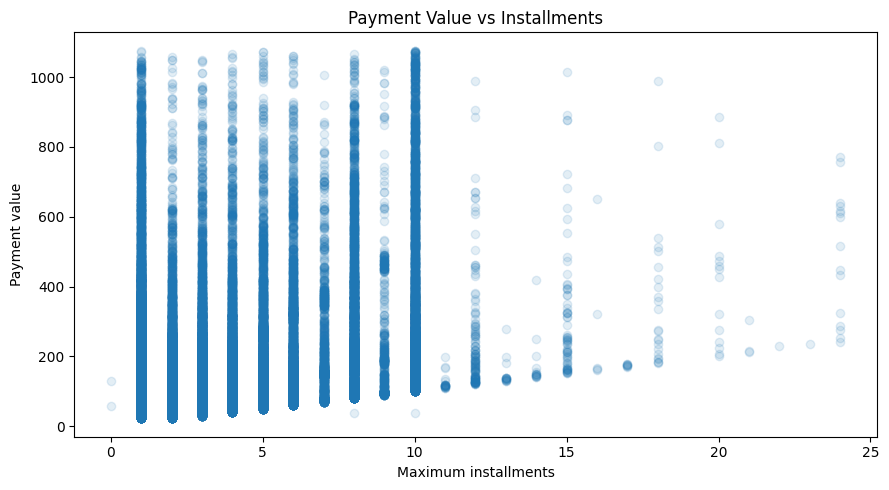

Saved figure: reports/figures/payment_value_vs_installments.png


In [12]:
installment_plot = installment_sample.loc[
    installment_sample["total_payment_value"].between(
        installment_sample["total_payment_value"].quantile(0.01),
        installment_sample["total_payment_value"].quantile(0.99),
    )
].copy()

plt.figure(figsize=(9, 5))
plt.scatter(installment_plot["max_installments"], installment_plot["total_payment_value"], alpha=0.12)
plt.title("Payment Value vs Installments")
plt.xlabel("Maximum installments")
plt.ylabel("Payment value")
plt.tight_layout()
installments_figure_path = FIGURES_DIR / "payment_value_vs_installments.png"
plt.savefig(installments_figure_path, dpi=150)
plt.show()
print(f"Saved figure: {installments_figure_path.relative_to(PROJECT_ROOT)}")

## 9. Question 4 — Do repeat customers have higher total customer value?

In [13]:
customer_value_sample = customer_level.loc[
    customer_level["total_payment_value"].notna()
    & customer_level["is_repeat_customer"].notna()
].copy()
customer_value_sample["customer_group"] = np.where(customer_value_sample["is_repeat_customer"], "repeat_customer", "one_time_customer")

customer_value_by_group = summarize_group(customer_value_sample, "customer_group", "total_payment_value")
customer_value_by_group

,customer_group,sample_size,mean_value,median_value,standard_deviation,minimum,maximum
0,one_time_customer,93099,161.815373,105.70,223.954515,0.00,13664.08
1,repeat_customer,2997,314.989226,225.84,369.591581,34.97,9553.02


In [14]:
repeat_values = customer_value_sample.loc[customer_value_sample["customer_group"].eq("repeat_customer"), "total_payment_value"]
one_time_values = customer_value_sample.loc[customer_value_sample["customer_group"].eq("one_time_customer"), "total_payment_value"]

customer_value_mannwhitney = stats.mannwhitneyu(repeat_values, one_time_values, alternative="two-sided")
customer_value_cohen_d = cohen_d(repeat_values, one_time_values)

add_test_result(
    question="Do repeat customers have different total customer value?",
    test_name="Mann-Whitney U test",
    sample_size=int(customer_value_sample.shape[0]),
    statistic=float(customer_value_mannwhitney.statistic),
    p_value=float(customer_value_mannwhitney.pvalue),
    effect_size_name="Cohen's d: repeat minus one-time",
    effect_size_value=float(customer_value_cohen_d),
    interpretation="Compares total customer value between repeat and one-time customers.",
)

pd.DataFrame(statistical_results).tail(1)

,question,test_name,sample_size,statistic,p_value,effect_size_name,effect_size_value,interpretation
3,Do repeat customers have different total custo...,Mann-Whitney U test,96096,215397680.5,0.0,Cohen's d: repeat minus one-time,0.666284,Compares total customer value between repeat a...


/tmp/ipykernel_715/4248443868.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([one_time_values.dropna(), repeat_values.dropna()], labels=["one_time_customer", "repeat_customer"], showfliers=False)


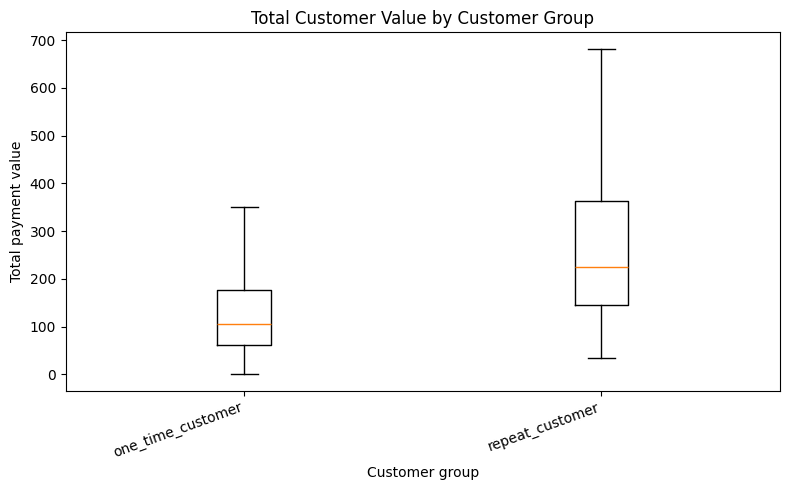

Saved figure: reports/figures/customer_value_by_customer_group.png


In [15]:
plt.figure(figsize=(8, 5))
plt.boxplot([one_time_values.dropna(), repeat_values.dropna()], labels=["one_time_customer", "repeat_customer"], showfliers=False)
plt.title("Total Customer Value by Customer Group")
plt.xlabel("Customer group")
plt.ylabel("Total payment value")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
customer_value_figure_path = FIGURES_DIR / "customer_value_by_customer_group.png"
plt.savefig(customer_value_figure_path, dpi=150)
plt.show()
print(f"Saved figure: {customer_value_figure_path.relative_to(PROJECT_ROOT)}")

## 10. Question 5 — Do review scores differ by payment type?

In [16]:
payment_review_sample = order_level.loc[
    order_level["main_payment_type"].notna()
    & order_level["average_review_score"].notna()
].copy()

payment_review_summary = summarize_group(payment_review_sample, "main_payment_type", "average_review_score")
payment_review_summary

,main_payment_type,sample_size,mean_value,median_value,standard_deviation,minimum,maximum
0,boleto,19636,4.087136,5.0,1.338037,1.0,5.0
1,credit_card,75538,4.088443,5.0,1.346840,1.0,5.0
2,debit_card,1521,4.169954,5.0,1.292773,1.0,5.0
3,not_defined,3,1.666667,1.0,1.154701,1.0,3.0
4,voucher,1974,3.961415,5.0,1.432862,1.0,5.0


In [17]:
payment_review_groups = [
    group["average_review_score"].dropna()
    for _, group in payment_review_sample.groupby("main_payment_type")
    if len(group["average_review_score"].dropna()) >= 10
]

kruskal_payment_review = stats.kruskal(*payment_review_groups)

add_test_result(
    question="Do review scores differ by main payment type?",
    test_name="Kruskal-Wallis test",
    sample_size=int(payment_review_sample.shape[0]),
    statistic=float(kruskal_payment_review.statistic),
    p_value=float(kruskal_payment_review.pvalue),
    interpretation="Compares review-score distributions across payment-type groups.",
)

pd.DataFrame(statistical_results).tail(1)

,question,test_name,sample_size,statistic,p_value,effect_size_name,effect_size_value,interpretation
4,Do review scores differ by main payment type?,Kruskal-Wallis test,98672,18.209293,0.000398,None,NaN,Compares review-score distributions across pay...


/tmp/ipykernel_715/3234350281.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_values, labels=payment_types, showfliers=False)


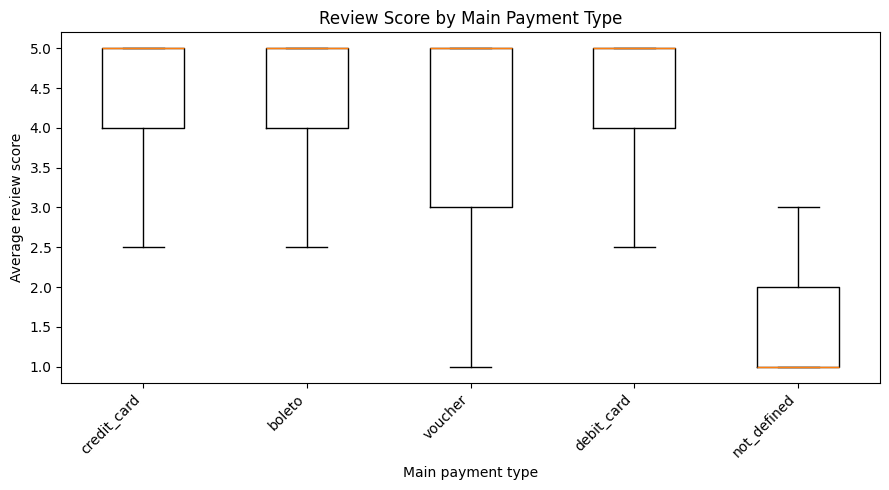

Saved figure: reports/figures/review_score_by_payment_type.png


In [18]:
payment_types = payment_review_sample["main_payment_type"].value_counts().index.tolist()
boxplot_values = [
    payment_review_sample.loc[payment_review_sample["main_payment_type"].eq(payment_type), "average_review_score"].dropna()
    for payment_type in payment_types
]

plt.figure(figsize=(9, 5))
plt.boxplot(boxplot_values, labels=payment_types, showfliers=False)
plt.title("Review Score by Main Payment Type")
plt.xlabel("Main payment type")
plt.ylabel("Average review score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
payment_review_figure_path = FIGURES_DIR / "review_score_by_payment_type.png"
plt.savefig(payment_review_figure_path, dpi=150)
plt.show()
print(f"Saved figure: {payment_review_figure_path.relative_to(PROJECT_ROOT)}")

## 11. Consolidated statistical results

In [19]:
statistical_test_results = pd.DataFrame(statistical_results)
statistical_test_results

,question,test_name,sample_size,statistic,p_value,effect_size_name,effect_size_value,interpretation
0,Are late deliveries associated with different ...,Mann-Whitney U test,95830,1.507169e+08,0.000000,Cohen's d: late minus on-time,-1.445458,Compares review-score distributions between la...
1,Is delivery delay correlated with review score?,Spearman correlation,95830,-1.755703e-01,0.000000,Spearman rho,-0.175570,Measures the monotonic association between del...
2,Are larger orders associated with more install...,Spearman correlation,99440,3.816806e-01,0.000000,Spearman rho,0.381681,Measures the monotonic association between pay...
3,Do repeat customers have different total custo...,Mann-Whitney U test,96096,2.153977e+08,0.000000,Cohen's d: repeat minus one-time,0.666284,Compares total customer value between repeat a...
4,Do review scores differ by main payment type?,Kruskal-Wallis test,98672,1.820929e+01,0.000398,None,NaN,Compares review-score distributions across pay...


## 12. Export statistical-analysis artifacts

In [20]:
statistical_outputs = {
    "statistical_test_results.csv": statistical_test_results,
    "review_by_delivery_group.csv": review_by_delivery_group,
    "installment_summary.csv": installment_summary,
    "customer_value_by_group.csv": customer_value_by_group,
    "payment_review_summary.csv": payment_review_summary,
}

for file_name, dataframe in statistical_outputs.items():
    output_path = PROCESSED_DATA_DIR / file_name
    dataframe.to_csv(output_path, index=False)
    print(f"Created: {output_path.relative_to(PROJECT_ROOT)}")

Created: data/processed/statistical_test_results.csv
Created: data/processed/review_by_delivery_group.csv
Created: data/processed/installment_summary.csv
Created: data/processed/customer_value_by_group.csv
Created: data/processed/payment_review_summary.csv


## 13. Create a Markdown statistical report

In [21]:
def dataframe_to_markdown_table(dataframe: pd.DataFrame, max_rows: int = 15) -> str:
    table = dataframe.head(max_rows).copy()
    if table.empty:
        return "_No records._"
    columns = [str(column) for column in table.columns]
    header = "| " + " | ".join(columns) + " |"
    separator = "| " + " | ".join(["---"] * len(columns)) + " |"
    rows = []
    for _, row in table.iterrows():
        values = [str(row[column]) for column in table.columns]
        rows.append("| " + " | ".join(values) + " |")
    return "\n".join([header, separator, *rows])

report_path = REPORTS_DIR / "statistical_analysis_report.md"
report_content = f"""# Statistical Analysis Report

## Project

Brazilian E-Commerce Analytics Portfolio

## Statistical Test Results

{dataframe_to_markdown_table(statistical_test_results, max_rows=20)}

## Review Score by Delivery Group

{dataframe_to_markdown_table(review_by_delivery_group)}

## Installment Summary

{dataframe_to_markdown_table(installment_summary, max_rows=20)}

## Customer Value by Customer Group

{dataframe_to_markdown_table(customer_value_by_group)}

## Review Score by Payment Type

{dataframe_to_markdown_table(payment_review_summary)}

## Interpretation Notes

- Statistical association does not imply causation.
- Mann-Whitney U tests compare distributions between two independent groups.
- Spearman correlation measures monotonic association and is robust for non-normal distributions.
- Kruskal-Wallis tests compare distributions across more than two groups.
- Effect sizes should be interpreted together with p-values and business relevance.
"""
report_path.write_text(report_content, encoding="utf-8")
print(f"Created report: {report_path.relative_to(PROJECT_ROOT)}")

Created report: reports/statistical_analysis_report.md


## Statistical analysis summary

This notebook compared review scores between late and on-time deliveries, tested the relationship between delivery delay and review score, analyzed the relationship between payment value and installments, compared total customer value between one-time and repeat customers, evaluated review-score differences by payment type, and exported statistical results, figures, and a Markdown report.